In [2]:
# from block_group_load_curves import *
# from location_str_to_geoid_mapping import *
# from public_chargers import *
from sklearn.metrics.pairwise import haversine_distances
import folium
from folium.features import GeoJsonTooltip
import pandas as pd
from pathlib import Path
import geopandas as gpd
import numpy as np
import json
import osmnx as ox
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx


In [3]:

print('='*10 + 'Start network file' + '='*10)

# =========================================================
# Find origin and destination energy demand and distances
# =========================================================

DATA_DIR = Path.cwd() / "data"

df = pd.read_parquet(DATA_DIR / 'network_analysis/df.parquet')
gdf_subset = pd.read_parquet(DATA_DIR / 'network_analysis/gdf_subset.parquet')
charger_df = pd.read_parquet(DATA_DIR / 'network_analysis/charger_df.parquet')
charger_gdf = gpd.read_parquet(DATA_DIR / 'network_analysis/charger_gdf.parquet')
gdf = gpd.read_parquet(DATA_DIR / 'network_analysis/gdf.parquet')
gdf_for_json = gpd.read_file(DATA_DIR / 'network_analysis/gdf.geojson')

with open((DATA_DIR / 'Geography_Files/location_str_to_geoid_mapping.json'), 'r') as f:
    mapping = json.load(f)

# Flatten column MultiIndex
df.columns = [
    '_'.join(col).strip() if isinstance(col, tuple) else col
    for col in df.columns.values
]

# Merge lat and lon data from GeoPandas df with block group data and map to census track
demand_df = df.merge(gdf_subset, on='geoid_str_', how='left')

# Filter df for data at only 6 pm
demand_df_filtered = demand_df[demand_df['hour_'] == pd.to_timedelta('18:00:00')]

# Drop locations with invalid coordinates
demand_df_filtered = demand_df_filtered.dropna(subset=['INTPTLAT', 'INTPTLON'])

# Take only locations from Alameda County
demand_df_filtered = demand_df_filtered[demand_df_filtered['geoid_str_'].str.contains('Alameda', case=False, na=False)]

# Compute mass
demand_df_filtered['mass'] = demand_df_filtered.loc[:, 'load_curve_MFH_LD_L2':'load_curve_Work_LD_L2'].sum(axis=1)

# Convert to radians for haversine calculation
coords = np.radians(demand_df_filtered[['INTPTLAT', 'INTPTLON']])
dist_matrix = haversine_distances(coords) * 6371

# Change dist matrix from array to pandas df
df_dist = pd.DataFrame(
    dist_matrix,
    columns=demand_df_filtered['geoid_str_'].values
).assign(geoid_str_=demand_df_filtered['geoid_str_'].values)[
    ['geoid_str_'] + demand_df_filtered['geoid_str_'].values.tolist()
]
# Set geo ids as index
df_dist = df_dist.set_index('geoid_str_')

# Map index values to geo id values
index = pd.Series(range(len(df_dist)), index=df_dist.index)



==========Start network file==========


In [4]:
# =========================================================
# Nearest neighbours
# =========================================================

# Take nearest neighbours data from location_str_to_geoid_mapping.py
network_df = gdf_subset.explode('NEIGHBOURS')

# Spatial join of charger location points and census track polygons to categorize each charger
# with its respective census track
charger_loc_gdf = gpd.sjoin(
    charger_gdf,
    gdf[["GEOID_STR", "geometry"]],
    how="left",
    predicate="within"
)
charger_loc_gdf = charger_loc_gdf.drop(columns=["index_right"])
charger_loc_gdf.rename(columns={"GEOID_STR": "geoid_str_"}, inplace=True)

# group chargers by geoid_str_ and aggregate into a list
chargers_per_tract = (
    charger_loc_gdf.groupby("geoid_str_")["ID"]
    .apply(list)
    .reset_index()  # convert back to DataFrame for merging
)

# First merge: origin chargers
network_df = network_df.merge(
    chargers_per_tract,
    how="left",
    left_on="geoid_str_",
    right_on="geoid_str_"
).rename(columns={"ID": "origin_chargers"}) 

# Second merge: destination chargers
network_df = network_df.merge(
    chargers_per_tract,
    how="left",
    left_on="NEIGHBOURS",
    right_on="geoid_str_"
).rename(columns={"ID": "destination_chargers"})

# fix column names
network_df = network_df.drop(columns=["geoid_str__y"])
network_df = network_df.rename(columns={"geoid_str__x": "geoid_str_"})



/var/folders/55/jq27sjjd46d27s__m84b78q40000gn/T/ipykernel_30985/1866869710.py:10: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  charger_loc_gdf = gpd.sjoin(


In [5]:
# =========================================================
# Simplify to Alameda County
# =========================================================

# Take only locations from Alameda County
network_df = network_df[network_df['geoid_str_'].str.contains('Alameda', case=False, na=False)]
network_df = network_df[network_df['NEIGHBOURS'].str.contains('Alameda', case=False, na=False)]

# Get demand for each census block
network_df = network_df.merge(demand_df_filtered[['geoid_str_', 'mass']], how='left', on='geoid_str_')
network_df = network_df.rename(columns={'mass':'origin_demand_(kW)'})

# Add destination mass here with df.merge
network_df = pd.merge(network_df, demand_df_filtered[['geoid_str_', 'mass']], left_on='NEIGHBOURS', right_on='geoid_str_', how='left')
network_df = network_df.rename(columns={'mass':'destination_demand_(kW)'})
network_df = network_df.rename(columns={'geoid_str__x': 'geoid_str_'}).drop(columns=['geoid_str__y'])

# Begin Add Haversine distances
# Lookup matrix positions
row_idx = index[network_df['geoid_str_']].values
col_idx = index[network_df['NEIGHBOURS']].values

# Extract distances
network_df['distance_km'] = dist_matrix[row_idx, col_idx]

# Adding location str mapping ids 
network_df['geoid'] = network_df['geoid_str_'].map(mapping)
network_df['neighbor_geoid'] = network_df['NEIGHBOURS'].map(mapping)

network_df.to_parquet(DATA_DIR / 'network_analysis/network_df.parquet')

# =============================================
# End origin-destination analysis
# =============================================



In [6]:
# =============================================
# Begin plot of heat map
# =============================================

# Alameda plot

alameda_gdf = gdf[['GEOID_STR', 'INTPTLAT', 'INTPTLON', 'geometry', 'NEIGHBOURS']]
alameda_gdf = alameda_gdf.rename(columns={'GEOID_STR': 'geoid_str_'})
alameda_gdf = alameda_gdf[alameda_gdf['geoid_str_'].str.contains('Alameda', case=False, na=False)]
alameda_gdf['charging_demand'] = demand_df_filtered['mass'].values

# =============================================
# Begin POI analysis
# =============================================

# Load tag dictionaries
ox.settings.use_cache = True
ox.settings.log_console = False
tab_buildings = pd.read_html('https://wiki.openstreetmap.org/wiki/Key:building', match='Value')[0]
tab_amenities = pd.read_html('https://wiki.openstreetmap.org/wiki/Key:amenity', match='Value')[0]
tab_shop = pd.read_html('https://wiki.openstreetmap.org/wiki/Key:shop', match='Value')[0]
tab_leisure = pd.read_html('https://wiki.openstreetmap.org/wiki/Key:leisure', match='Value')[0]

desired_buildings = ['office']
desired_amenities = ['fitness_center', 'fast_food', 'bank']
desired_shops = ['supermarket', 'mall']
desired_leisure = ['park']

# Get bounding box / polygon for Alameda only
alameda_poly = alameda_gdf.unary_union  # union for bounding box only, polygons still separate later

all_pois = []

# Download each category separately
poi_layers = {
    "building": desired_buildings,
    "amenity": desired_amenities,
    "shop": desired_shops,
    "leisure": desired_leisure
}

for key, values in poi_layers.items():
    pois = ox.geometries_from_polygon(
        alameda_poly,
        tags={key: values}
    )
    pois["poi_type"] = key
    all_pois.append(pois)

# Merge into one GeoDataFrame
pois_gdf = pd.concat(all_pois, ignore_index=True)
pois_gdf = pois_gdf.to_crs(alameda_gdf.crs)  # ensure same CRS

pois_joined = gpd.sjoin(
    pois_gdf,
    alameda_gdf[["geoid_str_", "geometry"]],
    how="left",
    predicate="within"
)

poi_counts = (
    pois_joined.groupby(["geoid_str_", "poi_type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

network_df = network_df.merge(
    poi_counts,
    how="left",
    on="geoid_str_"
)

# Replace NaN with zeros for blocks with no POIs
for c in ["amenity", "building", "shop", "leisure"]:
    if c in network_df.columns:
        network_df[c] = network_df[c].fillna(0)

# =============================================
# End POI analysis
# =============================================

# Simple heat map, keep for now
# fig, ax = plt.subplots(figsize=(10, 10))

# # Plot only the boundaries
# alameda_gdf.plot(
#     column = 'charging_demand',
#     cmap = 'Reds',
#     legend=True,
#     ax=ax, 
#     edgecolor='black', 
#     linewidth=0.8
# )

# # Optional: plot the geometries filled lightly
# # alameda_gdf.plot(ax=ax, color='lightblue', alpha=0.3, edgecolor='black')

# # Add titles and axes
# ax.set_title("EV Demand Heatmap - Alameda County", fontsize=14)
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")
# plt.show()

alameda_chargers = charger_loc_gdf.copy()
alameda_chargers = alameda_chargers[alameda_chargers['geoid_str_'].str.contains('Alameda', case=False, na=False)]

alameda_gdf = alameda_gdf.drop(columns=['NEIGHBOURS'])

# --- Create interactive map ---
m = folium.Map(
    location=[alameda_gdf['INTPTLAT'].mean(), alameda_gdf['INTPTLON'].mean()],
    zoom_start=10,
    tiles='cartodbpositron'
)

# Add choropleth for charging demand
folium.Choropleth(
    geo_data=alameda_gdf,
    name="Charging Demand",
    data=alameda_gdf,
    columns=["geoid_str_", "charging_demand"],
    key_on="feature.properties.geoid_str_",
    fill_color="Reds",
    fill_opacity=0.7,
    line_opacity=0.5,
    legend_name="EV Charging Demand (kW)"
).add_to(m)

# Add tract tooltips
folium.GeoJson(
    alameda_gdf,
    style_function=lambda x: {"fillColor": "transparent", "color": "black", "weight": 0.8},
    tooltip=GeoJsonTooltip(
        fields=["geoid_str_", "charging_demand"],
        aliases=["Tract:", "Charging demand:"],
        localize=True
    )
).add_to(m)

# Add chargers as points
for _, row in alameda_chargers.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=4,
        color='green',
        fill=True,
        fill_color='green',
        fill_opacity=0.7,
        popup=f"Charger ID: {row['ID']}"  # optional popup
    ).add_to(m)

    # Add census tract centroids as points
for _, row in alameda_gdf.iterrows():
    folium.CircleMarker(
        location=[row.geometry.centroid.y, row.geometry.centroid.x],
        radius=1,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.7,
        popup=f"Census Track ID: {row['geoid_str_']}"  # optional popup
    ).add_to(m)

# Convert all geometries to points for plotting
pois_gdf["plot_geom"] = pois_gdf.geometry.apply(
    lambda geom: geom.centroid if geom.geom_type != "Point" else geom
)
# Add POIs as points
for _, row in pois_gdf.iterrows():
    pt = row.plot_geom
    folium.CircleMarker(
        location=[pt.y, pt.x],
        radius=1,
        color='purple',
        fill=True,
        fill_color='purple',
        fill_opacity=0.6
    ).add_to(m)

# --- Add Custom HTML Legend for Markers ---
legend_html = """
     <div style="position: fixed; 
     bottom: 50px; left: 50px; width: 200px; height: 90px; 
     border:2px solid grey; z-index:9999; font-size:14px;
     background-color:white; opacity: 0.9;">
       &nbsp; <b>Map Legend</b> <br>
       &nbsp; <i style="background:green; color:green; border-radius:50%; margin-top: 5px; width: 10px; height: 10px; display:inline-block;"></i> &nbsp; Charging Station<br>
       &nbsp; <i style="background:blue; color:blue; border-radius:50%; margin-top: 5px; width: 10px; height: 10px; display:inline-block;"></i> &nbsp; Census Block Centroid<br>
       &nbsp; <i style="background:purple; color:purple; border-radius:50%; margin-top: 5px; width: 10px; height: 10px; display:inline-block;"></i> &nbsp; POI<br>
     </div>
     """
m.get_root().html.add_child(folium.Element(legend_html))
# --- End Custom HTML Legend ---

# --- Save and open map ---
output_file = "alameda_charging_map.html"
m.save(output_file)
print(f"Interactive map saved as {output_file}. Open this file in a web browser to explore.")

# Alameda Charger Type Counts
# ================================================
print(alameda_chargers.head())
print(len(alameda_chargers))
print(charger_df[['EV Level1 EVSE Num', 'EV Level2 EVSE Num', 'EV DC Fast Count']].head())
print(f"Level 1 Charger Total: {alameda_chargers['EV Level1 EVSE Num'].sum()}")
print(f"Level 2 Charger Total: {alameda_chargers['EV Level2 EVSE Num'].sum()}")
print(f"DC Fast Charger Total: {alameda_chargers['EV DC Fast Count'].sum()}")
print(f"Level 1 Station Total: {alameda_chargers['EV Level1 EVSE Num'].count()}")
print(f"Level 2 Station Total: {alameda_chargers['EV Level2 EVSE Num'].count()}")
print(f"DC Fast Station Total: {alameda_chargers['EV DC Fast Count'].count()}")

# Uniqueness Counts
# ================================================
print(network_df['geoid_str_'].nunique())
print(len(network_df['geoid_str_']))
print(alameda_chargers.head())
print(len(alameda_chargers['geoid_str_']))
print(alameda_chargers['geoid_str_'].nunique())

print('='*10 + 'Finish network file' + '='*10)










Interactive map saved as alameda_charging_map.html. Open this file in a web browser to explore.
        ID           Access Days Time  EV Level1 EVSE Num  EV Level2 EVSE Num  \
71   33695    24 hours daily; pay lot                 NaN                 4.0   
101  39893  Dealership business hours                 NaN                 2.0   
108  39901  Dealership business hours                 NaN                 2.0   
139  39937  Dealership business hours                 NaN                 2.0   
157  45313             24 hours daily                 NaN                 1.0   

     EV DC Fast Count   Latitude   Longitude                     geometry  \
71                NaN  37.713600 -122.208700  POINT (-122.20870 37.71360)   
101               1.0  37.498640 -121.973400  POINT (-121.97340 37.49864)   
108               1.0  37.662305 -122.075178  POINT (-122.07518 37.66231)   
139               1.0  37.712670 -122.162450  POINT (-122.16245 37.71267)   
157               NaN  37.702909

In [7]:
# pois_gdf
# alameda_gdf
# network_df
network_df['POI_SCORE'] = network_df['building']*3+network_df['shop']*2+network_df['leisure']*2+network_df['amenity']
network_df = network_df.drop(['building', 'shop', 'leisure', 'amenity'], axis=1)
network_df

,geoid_str_,INTPTLAT,INTPTLON,NEIGHBOURS,origin_chargers,destination_chargers,origin_demand_(kW),destination_demand_(kW),distance_km,geoid,neighbor_geoid,POI_SCORE
0,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"1 (Tract 4233, Alameda, CA)",[333026],NaN,568.288007,274.272001,0.760447,060014232002,060014233001,0.0
1,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"4 (Tract 4231, Alameda, CA)",[333026],NaN,568.288007,433.504001,0.668007,060014232002,060014231004,0.0
2,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"1 (Tract 4220, Alameda, CA)",[333026],"[161015, 205385, 220218, 220219, 308753, 32132...",568.288007,2937.020025,0.823073,060014232002,060014220001,0.0
3,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"3 (Tract 4231, Alameda, CA)",[333026],NaN,568.288007,178.240000,0.667594,060014232002,060014231003,0.0
4,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"2 (Tract 4231, Alameda, CA)",[333026],NaN,568.288007,637.020002,0.707463,060014232002,060014231002,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
7271,"1 (Tract 4323, Alameda, CA)",37.734870,-122.167514,"3 (Tract 4104, Alameda, CA)",NaN,[312147],490.880003,928.864010,0.667486,060014323001,060014104003,0.0
7272,"1 (Tract 4323, Alameda, CA)",37.734870,-122.167514,"3 (Tract 4323, Alameda, CA)",NaN,NaN,490.880003,1464.864024,0.686872,060014323001,060014323003,0.0
7273,"1 (Tract 4323, Alameda, CA)",37.734870,-122.167514,"2 (Tract 4323, Alameda, CA)",NaN,NaN,490.880003,255.136003,0.319092,060014323001,060014323002,0.0
7274,"1 (Tract 4323, Alameda, CA)",37.734870,-122.167514,"4 (Tract 4093, Alameda, CA)",NaN,NaN,490.880003,335.424005,0.550617,060014323001,060014093004,0.0


In [8]:
alameda_gdf['centroid'] = alameda_gdf.geometry.centroid
pois_joined = gpd.sjoin(
    pois_gdf,
    alameda_gdf[['geoid_str_', 'centroid', 'geometry']],
    how='left',
    predicate='within'
)
pois_joined = pois_joined.dropna(subset=["centroid"])


/var/folders/55/jq27sjjd46d27s__m84b78q40000gn/T/ipykernel_30985/1775708633.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  alameda_gdf['centroid'] = alameda_gdf.geometry.centroid


In [9]:
distances = []

for _, poi in pois_joined.iterrows():
    poi_rad = np.radians([poi.plot_geom.y, poi.plot_geom.x])
    centroid_rad = np.radians([poi.centroid.y, poi.centroid.x])

    d_rad = haversine_distances([poi_rad], [centroid_rad])[0][0]
    d_m = d_rad * 6371

    distances.append(d_m)

pois_joined["dist_to_centroid_km"] = distances


In [10]:
pois_joined

,addr:city,addr:country,addr:housenumber,addr:state,addr:street,geometry,amenity,addr:postcode,building,email,...,surface,covered,opening_hours:covid19,swimming_pool,abandoned:leisure,plot_geom,index_right,geoid_str_,centroid,dist_to_centroid_km
0,Fremont,NaN,44053,NaN,Fremont Boulevard,POINT (-121.95017 37.50868),NaN,94538,office,info@digital-nirvana.com,...,NaN,NaN,NaN,NaN,NaN,POINT (-121.95017 37.50868),6757.0,"2 (Tract 4415.03, Alameda, CA)",POINT (-121.95870 37.48611),2.619896
1,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-122.26004 37.79211, -122.25965 37.7...",NaN,NaN,office,NaN,...,NaN,NaN,NaN,NaN,NaN,POINT (-122.25956 37.79219),27386.0,"1 (Tract 4060, Alameda, CA)",POINT (-122.24922 37.78468),1.234117
2,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-122.26099 37.79218, -122.26059 37.7...",NaN,NaN,office,NaN,...,NaN,NaN,NaN,NaN,NaN,POINT (-122.26096 37.79257),27386.0,"1 (Tract 4060, Alameda, CA)",POINT (-122.24922 37.78468),1.353596
3,Oakland,NaN,300,CA,Lakeside Drive,"POLYGON ((-122.26477 37.80871, -122.26458 37.8...",NaN,94612,office,NaN,...,NaN,NaN,NaN,NaN,NaN,POINT (-122.26406 37.80877),12809.0,"1 (Tract 4029, Alameda, CA)",POINT (-122.26681 37.80756),0.276505
4,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-122.26905 37.87944, -122.26890 37.8...",NaN,NaN,office,NaN,...,NaN,NaN,NaN,NaN,NaN,POINT (-122.26891 37.87941),5986.0,"3 (Tract 4217, Alameda, CA)",POINT (-122.26986 37.87920),0.086100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2267,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-122.28870 37.78989, -122.28837 37.7...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,POINT (-122.28803 37.78894),17940.0,"3 (Tract 4287, Alameda, CA)",POINT (-122.28463 37.78927),0.300498
2268,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.29587 37.78173, -122.2948...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,POINT (-122.29391 37.78153),13168.0,"2 (Tract 4287, Alameda, CA)",POINT (-122.31128 37.78209),1.527981
2269,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-122.32836 37.82104, -122.32843 37.8...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,POINT (-122.32072 37.82212),22739.0,"3 (Tract 4017, Alameda, CA)",POINT (-122.31525 37.82110),0.493302
2270,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-122.30332 37.88589, -122.30343 37.8...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,POINT (-122.30276 37.88677),10193.0,"1 (Tract 4204.02, Alameda, CA)",POINT (-122.31930 37.88477),1.468972


In [11]:
avg_distances = pois_joined.groupby("geoid_str_")["dist_to_centroid_km"].mean().reset_index()
avg_distances = avg_distances.rename(columns={"dist_to_centroid_km": "avg_poi_dist_km"})

In [12]:
alameda_gdf = alameda_gdf.merge(avg_distances, how="left", on="geoid_str_")
alameda_gdf["avg_poi_dist_km"] = alameda_gdf["avg_poi_dist_km"].fillna(0)

In [13]:
alameda_gdf

,geoid_str_,INTPTLAT,INTPTLON,geometry,charging_demand,centroid,avg_poi_dist_km
0,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"POLYGON ((-122.29678 37.86529, -122.29581 37.8...",70.000000,POINT (-122.29324 37.86250),0.000000
1,"2 (Tract 4043, Alameda, CA)",37.844708,-122.241138,"POLYGON ((-122.24813 37.84139, -122.24749 37.8...",1416.240026,POINT (-122.24114 37.84471),0.195153
2,"2 (Tract 4062.02, Alameda, CA)",37.780027,-122.228022,"POLYGON ((-122.23135 37.78091, -122.23094 37.7...",591.008007,POINT (-122.22802 37.78003),0.115598
3,"3 (Tract 4327, Alameda, CA)",37.725139,-122.144137,"POLYGON ((-122.14781 37.72717, -122.14747 37.7...",466.080012,POINT (-122.14414 37.72514),0.000000
4,"2 (Tract 4415.23, Alameda, CA)",37.562874,-122.047237,"POLYGON ((-122.05046 37.56347, -122.05029 37.5...",490.551999,POINT (-122.04724 37.56287),0.000000
...,...,...,...,...,...,...,...
1129,"1 (Tract 4218, Alameda, CA)",37.881220,-122.276240,"POLYGON ((-122.28029 37.88244, -122.28010 37.8...",392.800002,POINT (-122.27624 37.88122),0.000000
1130,"1 (Tract 4301.02, Alameda, CA)",37.767498,-122.050012,"POLYGON ((-122.17916 37.80498, -122.17914 37.8...",620.832014,POINT (-122.08206 37.76698),6.172167
1131,"3 (Tract 4202, Alameda, CA)",37.892831,-122.298443,"POLYGON ((-122.30059 37.89504, -122.30046 37.8...",302.176010,POINT (-122.29844 37.89283),0.235346
1132,"1 (Tract 4203.01, Alameda, CA)",37.894735,-122.304795,"POLYGON ((-122.30878 37.89778, -122.30684 37.8...",545.952022,POINT (-122.30480 37.89473),0.293577


In [14]:
alameda_gdf

,geoid_str_,INTPTLAT,INTPTLON,geometry,charging_demand,centroid,avg_poi_dist_km
0,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"POLYGON ((-122.29678 37.86529, -122.29581 37.8...",70.000000,POINT (-122.29324 37.86250),0.000000
1,"2 (Tract 4043, Alameda, CA)",37.844708,-122.241138,"POLYGON ((-122.24813 37.84139, -122.24749 37.8...",1416.240026,POINT (-122.24114 37.84471),0.195153
2,"2 (Tract 4062.02, Alameda, CA)",37.780027,-122.228022,"POLYGON ((-122.23135 37.78091, -122.23094 37.7...",591.008007,POINT (-122.22802 37.78003),0.115598
3,"3 (Tract 4327, Alameda, CA)",37.725139,-122.144137,"POLYGON ((-122.14781 37.72717, -122.14747 37.7...",466.080012,POINT (-122.14414 37.72514),0.000000
4,"2 (Tract 4415.23, Alameda, CA)",37.562874,-122.047237,"POLYGON ((-122.05046 37.56347, -122.05029 37.5...",490.551999,POINT (-122.04724 37.56287),0.000000
...,...,...,...,...,...,...,...
1129,"1 (Tract 4218, Alameda, CA)",37.881220,-122.276240,"POLYGON ((-122.28029 37.88244, -122.28010 37.8...",392.800002,POINT (-122.27624 37.88122),0.000000
1130,"1 (Tract 4301.02, Alameda, CA)",37.767498,-122.050012,"POLYGON ((-122.17916 37.80498, -122.17914 37.8...",620.832014,POINT (-122.08206 37.76698),6.172167
1131,"3 (Tract 4202, Alameda, CA)",37.892831,-122.298443,"POLYGON ((-122.30059 37.89504, -122.30046 37.8...",302.176010,POINT (-122.29844 37.89283),0.235346
1132,"1 (Tract 4203.01, Alameda, CA)",37.894735,-122.304795,"POLYGON ((-122.30878 37.89778, -122.30684 37.8...",545.952022,POINT (-122.30480 37.89473),0.293577


In [15]:
# --- Create interactive map ---
m2 = folium.Map(
    location=[alameda_gdf['INTPTLAT'].mean(), alameda_gdf['INTPTLON'].mean()],
    zoom_start=10,
    tiles='cartodbpositron'
)

# Add choropleth for charging demand
folium.Choropleth(
    geo_data=alameda_gdf.drop(columns=['centroid']),
    name="Avg POI Distance to Centroid",
    data=alameda_gdf,
    columns=["geoid_str_", "avg_poi_dist_km"],
    key_on="feature.properties.geoid_str_",
    fill_color="Purples",
    fill_opacity=0.7,
    line_opacity=0.5,
    legend_name="Avg POI Distance (km)"
).add_to(m2)

# Add tract tooltips
folium.GeoJson(
    alameda_gdf.drop(columns=['centroid']),
    style_function=lambda x: {"fillColor": "transparent", "color": "black", "weight": 0.8},
    tooltip=GeoJsonTooltip(
        fields=["geoid_str_", "charging_demand"],
        aliases=["Tract:", "Charging demand:"],
        localize=True
    )
).add_to(m2)

    # Add census tract centroids as points
for _, row in alameda_gdf.iterrows():
    folium.CircleMarker(
        location=[row.geometry.centroid.y, row.geometry.centroid.x],
        radius=1,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.7,
        popup=f"Census Track ID: {row['geoid_str_']}"  # optional popup
    ).add_to(m2)

# Convert all geometries to points for plotting
pois_gdf["plot_geom"] = pois_gdf.geometry.apply(
    lambda geom: geom.centroid if geom.geom_type != "Point" else geom
)
# Add POIs as points
for _, row in pois_gdf.iterrows():
    pt = row.plot_geom
    folium.CircleMarker(
        location=[pt.y, pt.x],
        radius=1,
        color='purple',
        fill=True,
        fill_color='purple',
        fill_opacity=0.6
    ).add_to(m2)

# --- Add Custom HTML Legend for Markers ---
legend_html = """
     <div style="position: fixed; 
     bottom: 50px; left: 50px; width: 200px; height: 90px; 
     border:2px solid grey; z-index:9999; font-size:14px;
     background-color:white; opacity: 0.9;">
       &nbsp; <b>Map Legend</b> <br>
       &nbsp; <i style="background:blue; color:blue; border-radius:50%; margin-top: 5px; width: 10px; height: 10px; display:inline-block;"></i> &nbsp; Census Block Centroid<br>
       &nbsp; <i style="background:purple; color:purple; border-radius:50%; margin-top: 5px; width: 10px; height: 10px; display:inline-block;"></i> &nbsp; POI<br>
     </div>
     """
m2.get_root().html.add_child(folium.Element(legend_html))
# --- End Custom HTML Legend ---

# --- Save and open map ---
output_file = "alameda_POI_map.html"
m2.save(output_file)
print(f"Interactive map saved as {output_file}. Open this file in a web browser to explore.")

Interactive map saved as alameda_POI_map.html. Open this file in a web browser to explore.


In [16]:
alameda_chargers

,ID,Access Days Time,EV Level1 EVSE Num,EV Level2 EVSE Num,EV DC Fast Count,Latitude,Longitude,geometry,geoid_str_
71,33695,24 hours daily; pay lot,NaN,4.0,NaN,37.713600,-122.208700,POINT (-122.20870 37.71360),"2 (Tract 4090, Alameda, CA)"
101,39893,Dealership business hours,NaN,2.0,1.0,37.498640,-121.973400,POINT (-121.97340 37.49864),"2 (Tract 4415.03, Alameda, CA)"
108,39901,Dealership business hours,NaN,2.0,1.0,37.662305,-122.075178,POINT (-122.07518 37.66231),"3 (Tract 4365, Alameda, CA)"
139,39937,Dealership business hours,NaN,2.0,1.0,37.712670,-122.162450,POINT (-122.16245 37.71267),"1 (Tract 4325.01, Alameda, CA)"
157,45313,24 hours daily,NaN,1.0,NaN,37.702909,-121.918350,POINT (-121.91835 37.70291),"2 (Tract 4503, Alameda, CA)"
...,...,...,...,...,...,...,...,...,...
18587,434845,24 hours daily,NaN,NaN,1.0,37.748341,-122.204836,POINT (-122.20484 37.74834),"3 (Tract 4090, Alameda, CA)"
18602,437598,24 hours daily,NaN,2.0,NaN,37.794611,-122.208256,POINT (-122.20826 37.79461),"3 (Tract 4066.01, Alameda, CA)"
18616,438156,24 hours daily; guest use only,NaN,4.0,NaN,37.655330,-122.069830,POINT (-122.06983 37.65533),"2 (Tract 4365, Alameda, CA)"
18666,440467,24 hours daily,NaN,NaN,8.0,37.657112,-121.898083,POINT (-121.89808 37.65711),"1 (Tract 4506.07, Alameda, CA)"


In [17]:
pois_joined

,addr:city,addr:country,addr:housenumber,addr:state,addr:street,geometry,amenity,addr:postcode,building,email,...,surface,covered,opening_hours:covid19,swimming_pool,abandoned:leisure,plot_geom,index_right,geoid_str_,centroid,dist_to_centroid_km
0,Fremont,NaN,44053,NaN,Fremont Boulevard,POINT (-121.95017 37.50868),NaN,94538,office,info@digital-nirvana.com,...,NaN,NaN,NaN,NaN,NaN,POINT (-121.95017 37.50868),6757.0,"2 (Tract 4415.03, Alameda, CA)",POINT (-121.95870 37.48611),2.619896
1,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-122.26004 37.79211, -122.25965 37.7...",NaN,NaN,office,NaN,...,NaN,NaN,NaN,NaN,NaN,POINT (-122.25956 37.79219),27386.0,"1 (Tract 4060, Alameda, CA)",POINT (-122.24922 37.78468),1.234117
2,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-122.26099 37.79218, -122.26059 37.7...",NaN,NaN,office,NaN,...,NaN,NaN,NaN,NaN,NaN,POINT (-122.26096 37.79257),27386.0,"1 (Tract 4060, Alameda, CA)",POINT (-122.24922 37.78468),1.353596
3,Oakland,NaN,300,CA,Lakeside Drive,"POLYGON ((-122.26477 37.80871, -122.26458 37.8...",NaN,94612,office,NaN,...,NaN,NaN,NaN,NaN,NaN,POINT (-122.26406 37.80877),12809.0,"1 (Tract 4029, Alameda, CA)",POINT (-122.26681 37.80756),0.276505
4,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-122.26905 37.87944, -122.26890 37.8...",NaN,NaN,office,NaN,...,NaN,NaN,NaN,NaN,NaN,POINT (-122.26891 37.87941),5986.0,"3 (Tract 4217, Alameda, CA)",POINT (-122.26986 37.87920),0.086100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2267,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-122.28870 37.78989, -122.28837 37.7...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,POINT (-122.28803 37.78894),17940.0,"3 (Tract 4287, Alameda, CA)",POINT (-122.28463 37.78927),0.300498
2268,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.29587 37.78173, -122.2948...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,POINT (-122.29391 37.78153),13168.0,"2 (Tract 4287, Alameda, CA)",POINT (-122.31128 37.78209),1.527981
2269,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-122.32836 37.82104, -122.32843 37.8...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,POINT (-122.32072 37.82212),22739.0,"3 (Tract 4017, Alameda, CA)",POINT (-122.31525 37.82110),0.493302
2270,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-122.30332 37.88589, -122.30343 37.8...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,POINT (-122.30276 37.88677),10193.0,"1 (Tract 4204.02, Alameda, CA)",POINT (-122.31930 37.88477),1.468972


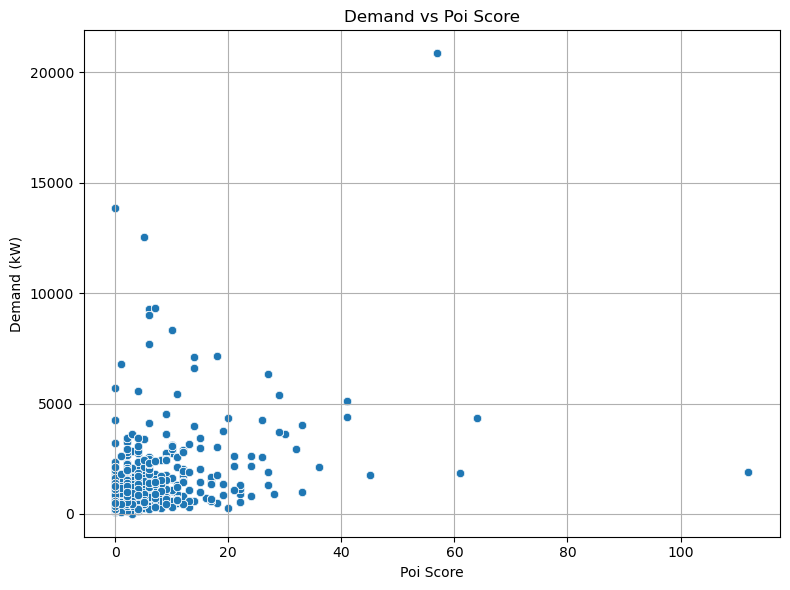

In [18]:
# Pick one:
x_var = "POI_SCORE"  # or "DEMAND_SCORE"
y_var = "origin_demand_(kW)"

# --- Plot ---
plt.figure(figsize=(8,6))
sns.scatterplot(data=network_df, x=x_var, y=y_var)

plt.xlabel(x_var.replace("_", " ").title())
plt.ylabel("Demand (kW)")
plt.title("Demand vs " + x_var.replace("_", " ").title())
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional correlation metric:
# corr = df[[x_var, y_var]].corr().iloc[0,1]
# print("Correlation:", corr)

In [19]:
network_df['total_chargers'] = network_df['origin_chargers'].apply(lambda x: len(x) if isinstance(x, list) else 0)
network_df

,geoid_str_,INTPTLAT,INTPTLON,NEIGHBOURS,origin_chargers,destination_chargers,origin_demand_(kW),destination_demand_(kW),distance_km,geoid,neighbor_geoid,POI_SCORE,total_chargers
0,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"1 (Tract 4233, Alameda, CA)",[333026],NaN,568.288007,274.272001,0.760447,060014232002,060014233001,0.0,1
1,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"4 (Tract 4231, Alameda, CA)",[333026],NaN,568.288007,433.504001,0.668007,060014232002,060014231004,0.0,1
2,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"1 (Tract 4220, Alameda, CA)",[333026],"[161015, 205385, 220218, 220219, 308753, 32132...",568.288007,2937.020025,0.823073,060014232002,060014220001,0.0,1
3,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"3 (Tract 4231, Alameda, CA)",[333026],NaN,568.288007,178.240000,0.667594,060014232002,060014231003,0.0,1
4,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"2 (Tract 4231, Alameda, CA)",[333026],NaN,568.288007,637.020002,0.707463,060014232002,060014231002,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7271,"1 (Tract 4323, Alameda, CA)",37.734870,-122.167514,"3 (Tract 4104, Alameda, CA)",NaN,[312147],490.880003,928.864010,0.667486,060014323001,060014104003,0.0,0
7272,"1 (Tract 4323, Alameda, CA)",37.734870,-122.167514,"3 (Tract 4323, Alameda, CA)",NaN,NaN,490.880003,1464.864024,0.686872,060014323001,060014323003,0.0,0
7273,"1 (Tract 4323, Alameda, CA)",37.734870,-122.167514,"2 (Tract 4323, Alameda, CA)",NaN,NaN,490.880003,255.136003,0.319092,060014323001,060014323002,0.0,0
7274,"1 (Tract 4323, Alameda, CA)",37.734870,-122.167514,"4 (Tract 4093, Alameda, CA)",NaN,NaN,490.880003,335.424005,0.550617,060014323001,060014093004,0.0,0


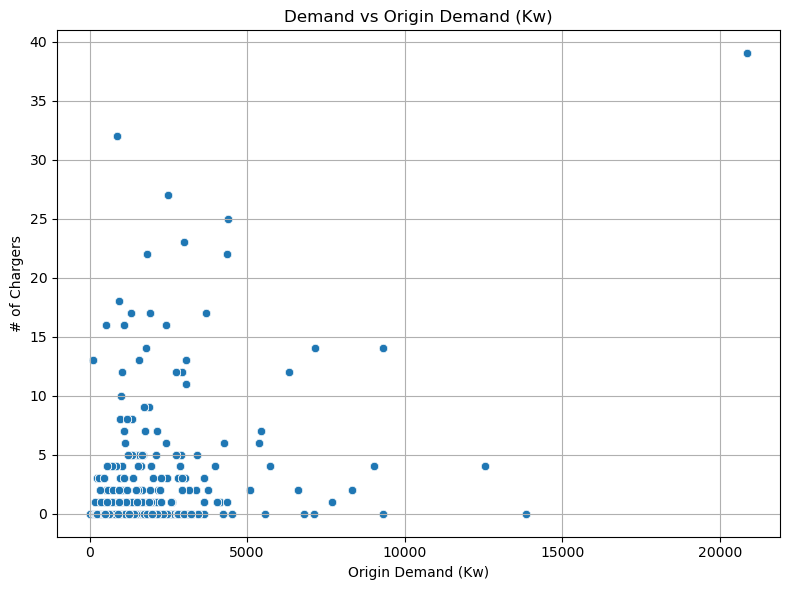

In [20]:
# Pick one:
x_var = "origin_demand_(kW)"  # or "DEMAND_SCORE"
y_var = "total_chargers"

# --- Plot ---
plt.figure(figsize=(8,6))
sns.scatterplot(data=network_df, x=x_var, y=y_var)

plt.xlabel(x_var.replace("_", " ").title())
plt.ylabel("# of Chargers")
plt.title("Demand vs " + x_var.replace("_", " ").title())
plt.grid(True)
plt.tight_layout()
plt.show()


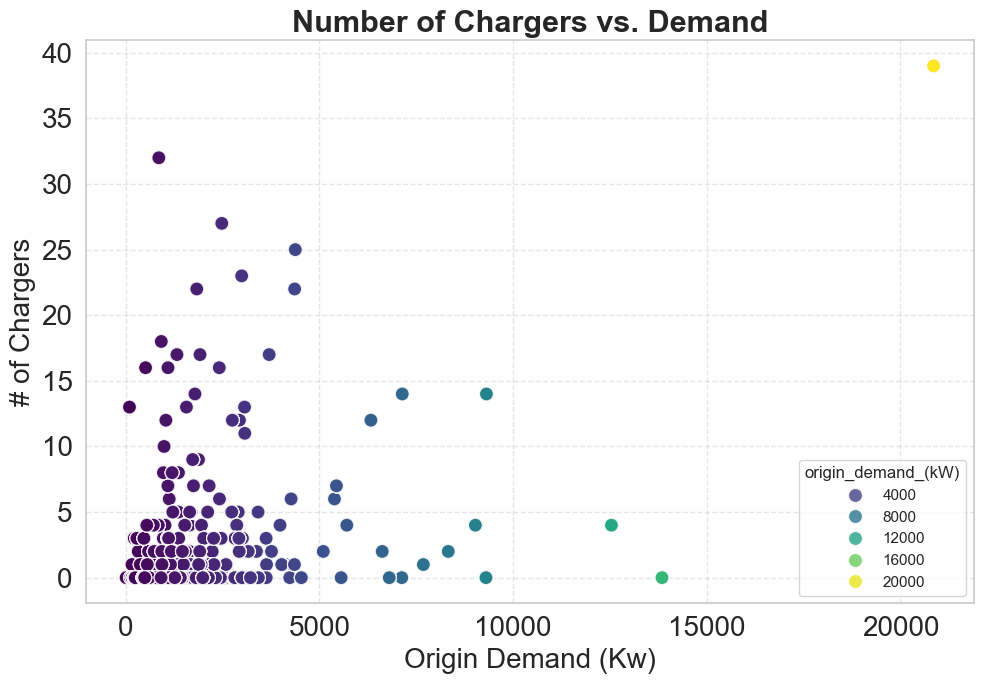

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose variables
x_var = "origin_demand_(kW)"  # or "DEMAND_SCORE"
y_var = "total_chargers"

# --- Set Seaborn style ---
sns.set_theme(style="whitegrid")  # clean background
palette = sns.color_palette("viridis", as_cmap=True)

# --- Plot ---
plt.figure(figsize=(10,7))
scatter = sns.scatterplot(
    data=network_df,
    x=x_var,
    y=y_var,
    hue=x_var,  # optional: color by x_var to show intensity
    palette=palette,
    edgecolor="w",
    s=100,      # larger points
    alpha=0.8
)

# --- Labels & Title ---
plt.xlabel(x_var.replace("_", " ").title(), fontsize=20)
plt.ylabel("# of Chargers", fontsize=20)
plt.title(f"Number of Chargers vs. Demand", fontsize=22, weight='bold')

# --- Ticks & Grid ---
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.5)

# --- Legend ---
if "hue" in scatter.get_legend().get_texts()[0].get_text():
    plt.legend(title=x_var.replace("_", " ").title(), fontsize=18, title_fontsize=20, loc='best')

plt.tight_layout()
plt.show()


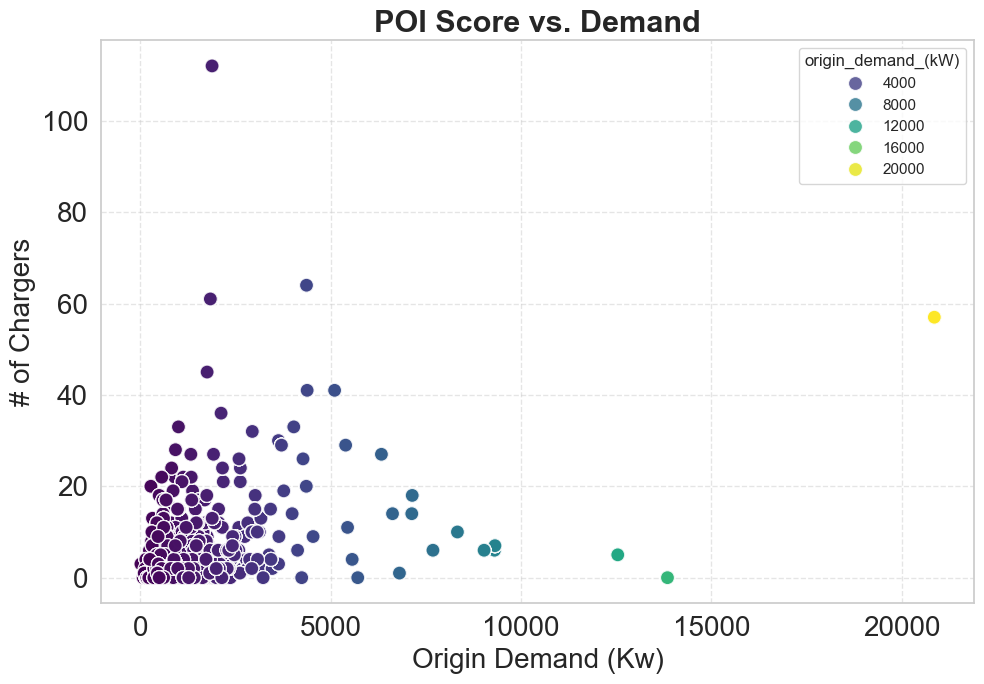

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose variables
x_var = "origin_demand_(kW)"  # or "DEMAND_SCORE"
y_var = "POI_SCORE"

# --- Set Seaborn style ---
sns.set_theme(style="whitegrid")  # clean background
palette = sns.color_palette("viridis", as_cmap=True)

# --- Plot ---
plt.figure(figsize=(10,7))
scatter = sns.scatterplot(
    data=network_df,
    x=x_var,
    y=y_var,
    hue=x_var,  # optional: color by x_var to show intensity
    palette=palette,
    edgecolor="w",
    s=100,      # larger points
    alpha=0.8
)

# --- Labels & Title ---
plt.xlabel(x_var.replace("_", " ").title(), fontsize=20)
plt.ylabel("# of Chargers", fontsize=20)
plt.title(f"POI Score vs. Demand", fontsize=22, weight='bold')

# --- Ticks & Grid ---
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.5)

# --- Legend ---
if "hue" in scatter.get_legend().get_texts()[0].get_text():
    plt.legend(title=x_var.replace("_", " ").title(), fontsize=18, title_fontsize=20, loc='best')

plt.tight_layout()
plt.show()


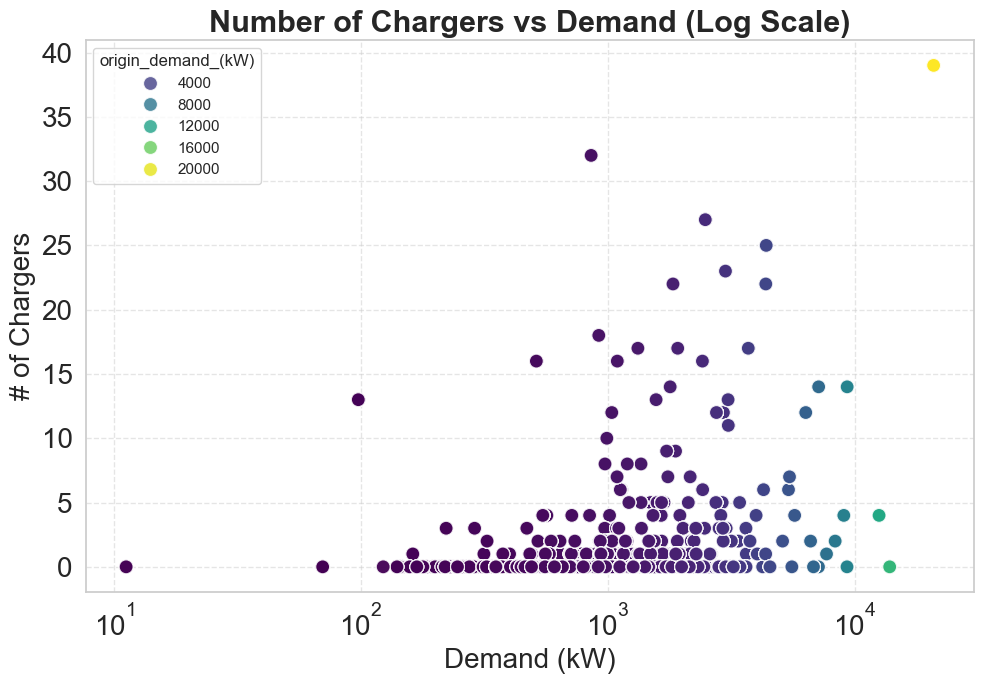

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose variables
x_var = "origin_demand_(kW)"  # or "DEMAND_SCORE"
y_var = "total_chargers"

# --- Seaborn style ---
sns.set_theme(style="whitegrid")
palette = sns.color_palette("viridis", as_cmap=True)

# --- Plot ---
plt.figure(figsize=(10,7))
scatter = sns.scatterplot(
    data=network_df,
    x=x_var,
    y=y_var,
    hue=x_var,          # optional coloring
    palette=palette,
    edgecolor="w",
    s=100,
    alpha=0.8
)

# --- Log scale ---
plt.xscale("log")
# plt.yscale("log")  # Uncomment if y also needs log scaling

# --- Labels & Title ---
plt.xlabel("Demand (kW)", fontsize=20)
plt.ylabel("# of Chargers", fontsize=20)
plt.title(f"Number of Chargers vs Demand (Log Scale)", fontsize=22, weight='bold')

# --- Ticks & Grid ---
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.5)

# --- Legend ---
if "hue" in scatter.get_legend().get_texts()[0].get_text():
    plt.legend(title=x_var.replace("_", " ").title(), fontsize=20, title_fontsize=20, loc='best')

plt.tight_layout()
plt.show()


In [24]:
# Find the row with the maximum number of chargers
max_chargers_row = network_df.loc[network_df['total_chargers'].idxmax()]

# Extract the GEOID_STR
max_chargers_geoid = max_chargers_row['geoid_str_']  # replace with your actual column name if different
max_chargers_count = max_chargers_row['total_chargers']

print(f"The GEOID_STR with the most chargers is {max_chargers_geoid}, with {max_chargers_count} chargers.")


The GEOID_STR with the most chargers is 2 (Tract 4415.03, Alameda, CA), with 39 chargers.


In [25]:
# Keep only the first occurrence of each GEOID_STR
unique_origins = network_df.drop_duplicates(subset='geoid_str_')

# Get top 3 by total_chargers
top3_origins = unique_origins.nlargest(10, 'total_chargers')

print(top3_origins[['geoid_str_', 'total_chargers']])
print(sum(top3_origins['total_chargers']))


                          geoid_str_  total_chargers
1969  2 (Tract 4415.03, Alameda, CA)              39
4574     1 (Tract 4031, Alameda, CA)              32
5376  4 (Tract 4283.01, Alameda, CA)              27
1222  1 (Tract 4501.02, Alameda, CA)              25
116   1 (Tract 4415.25, Alameda, CA)              23
3534     1 (Tract 4029, Alameda, CA)              22
4154  4 (Tract 4419.23, Alameda, CA)              22
6507  3 (Tract 4229.02, Alameda, CA)              18
1752  2 (Tract 4507.43, Alameda, CA)              17
4220  3 (Tract 4415.25, Alameda, CA)              17
242


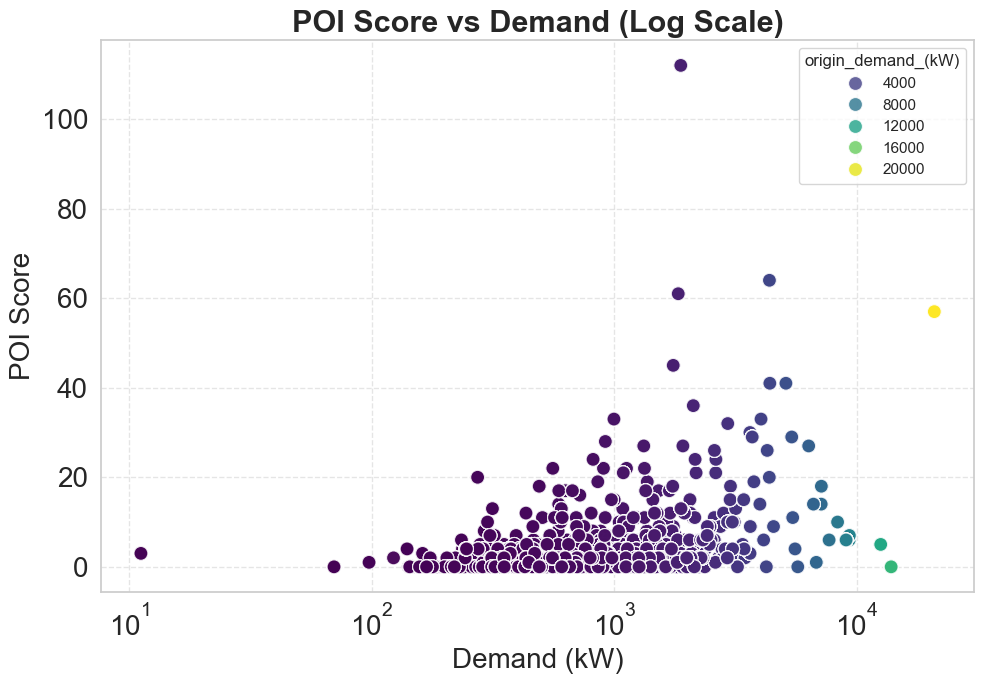

In [26]:
# Choose variables
x_var = "origin_demand_(kW)"  # or "DEMAND_SCORE"
y_var = "POI_SCORE"

# --- Seaborn style ---
sns.set_theme(style="whitegrid")
palette = sns.color_palette("viridis", as_cmap=True)

# --- Plot ---
plt.figure(figsize=(10,7))
scatter = sns.scatterplot(
    data=network_df,
    x=x_var,
    y=y_var,
    hue=x_var,          # optional coloring
    palette=palette,
    edgecolor="w",
    s=100,
    alpha=0.8
)

# --- Log scale ---
plt.xscale("log")
# plt.yscale("log")  # Uncomment if y also needs log scaling

# --- Labels & Title ---
plt.xlabel("Demand (kW)", fontsize=20)
plt.ylabel("POI Score", fontsize=20)
plt.title(f"POI Score vs Demand (Log Scale)", fontsize=22, weight='bold')

# --- Ticks & Grid ---
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.5)

# --- Legend ---
if "hue" in scatter.get_legend().get_texts()[0].get_text():
    plt.legend(title=x_var.replace("_", " ").title(), fontsize=20, title_fontsize=20, loc='best')

plt.tight_layout()
plt.show()


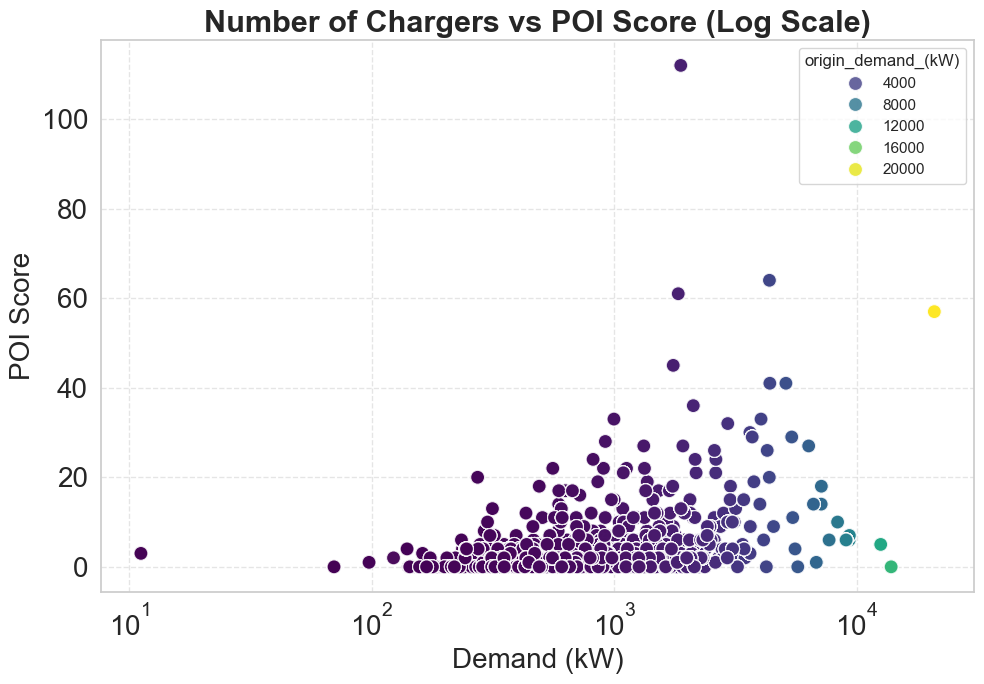

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose variables
x_var = "origin_demand_(kW)"  # or "DEMAND_SCORE"
y_var = "POI_SCORE"

# --- Seaborn style ---
sns.set_theme(style="whitegrid")
palette = sns.color_palette("viridis", as_cmap=True)

# --- Plot ---
plt.figure(figsize=(10,7))
scatter = sns.scatterplot(
    data=network_df,
    x=x_var,
    y=y_var,
    hue=x_var,          # optional coloring
    palette=palette,
    edgecolor="w",
    s=100,
    alpha=0.8
)

# --- Log scale ---
plt.xscale("log")
# plt.yscale("log")  # Uncomment if y also needs log scaling

# --- Labels & Title ---
plt.xlabel("Demand (kW)", fontsize=20)
plt.ylabel("POI Score", fontsize=20)
plt.title(f"Number of Chargers vs POI Score (Log Scale)", fontsize=22, weight='bold')

# --- Ticks & Grid ---
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.5)

# --- Legend ---
if "hue" in scatter.get_legend().get_texts()[0].get_text():
    plt.legend(title=x_var.replace("_", " ").title(), fontsize=20, title_fontsize=20, loc='best')

plt.tight_layout()
plt.show()


In [28]:
network_df

,geoid_str_,INTPTLAT,INTPTLON,NEIGHBOURS,origin_chargers,destination_chargers,origin_demand_(kW),destination_demand_(kW),distance_km,geoid,neighbor_geoid,POI_SCORE,total_chargers
0,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"1 (Tract 4233, Alameda, CA)",[333026],NaN,568.288007,274.272001,0.760447,060014232002,060014233001,0.0,1
1,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"4 (Tract 4231, Alameda, CA)",[333026],NaN,568.288007,433.504001,0.668007,060014232002,060014231004,0.0,1
2,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"1 (Tract 4220, Alameda, CA)",[333026],"[161015, 205385, 220218, 220219, 308753, 32132...",568.288007,2937.020025,0.823073,060014232002,060014220001,0.0,1
3,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"3 (Tract 4231, Alameda, CA)",[333026],NaN,568.288007,178.240000,0.667594,060014232002,060014231003,0.0,1
4,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"2 (Tract 4231, Alameda, CA)",[333026],NaN,568.288007,637.020002,0.707463,060014232002,060014231002,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7271,"1 (Tract 4323, Alameda, CA)",37.734870,-122.167514,"3 (Tract 4104, Alameda, CA)",NaN,[312147],490.880003,928.864010,0.667486,060014323001,060014104003,0.0,0
7272,"1 (Tract 4323, Alameda, CA)",37.734870,-122.167514,"3 (Tract 4323, Alameda, CA)",NaN,NaN,490.880003,1464.864024,0.686872,060014323001,060014323003,0.0,0
7273,"1 (Tract 4323, Alameda, CA)",37.734870,-122.167514,"2 (Tract 4323, Alameda, CA)",NaN,NaN,490.880003,255.136003,0.319092,060014323001,060014323002,0.0,0
7274,"1 (Tract 4323, Alameda, CA)",37.734870,-122.167514,"4 (Tract 4093, Alameda, CA)",NaN,NaN,490.880003,335.424005,0.550617,060014323001,060014093004,0.0,0


In [29]:
G = nx.from_pandas_edgelist(network_df, source='geoid_str_', target='NEIGHBOURS', edge_attr='distance_km')

In [30]:
N = G.number_of_nodes()
total_degree_sum = sum(dict(G.degree()).values())
avg_degree = total_degree_sum / N
avg_degree

6.416225749559083

In [31]:
if nx.is_connected(G):
    # Calculate the average shortest path length (unweighted by default)
    avg_distance = nx.average_shortest_path_length(G, weight=None)
    # print(f"Average Distance: {avg_distance}")
else:
    avg_distance = "Graph is disconnected, average distance is undefined for the whole graph."
    # You could analyze components individually if needed

In [32]:
avg_distance

8.140925357753837

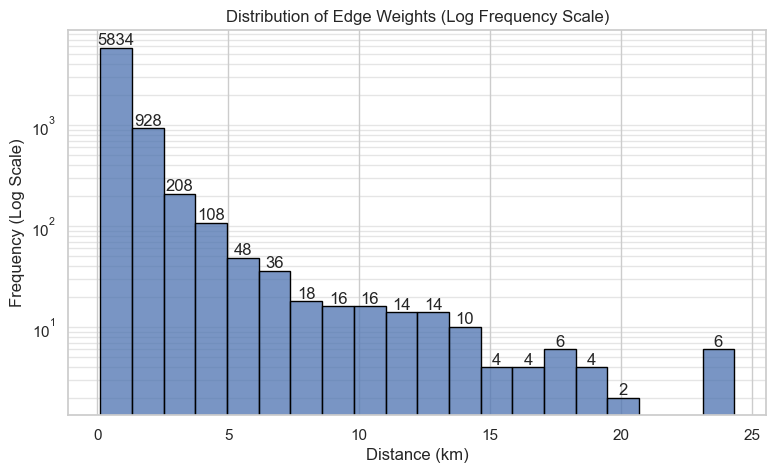

In [33]:
plt.figure(figsize=(9, 5))

sns.set_style("whitegrid")

# Create the histplot first and store the axes object
ax = sns.histplot(
    data=network_df,
    x='distance_km',
    bins=20,         # Adjust bins as needed for the x-axis values
    kde=False,
    edgecolor='black',
    linewidth=1
)

for container in ax.containers:
    # ax.bar_label automatically labels the bars with their heights (frequencies)
    # You can set the format (fmt) to ensure they are integers if needed
    ax.bar_label(container, fmt='%g', label_type='edge')

# Set the y-axis (frequency count) to a logarithmic scale
ax.set_yscale('log')

plt.title('Distribution of Edge Weights (Log Frequency Scale)')
plt.xlabel('Distance (km)')
plt.ylabel('Frequency (Log Scale)')
plt.grid(axis='y', alpha=0.5, which='both')
plt.show()

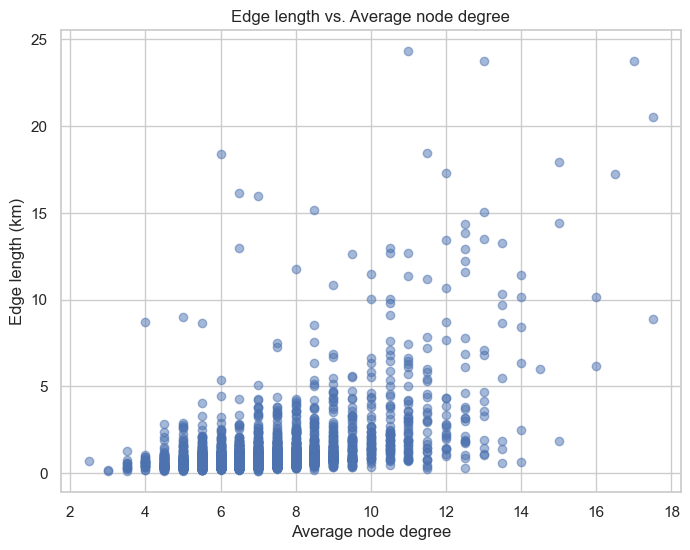

In [34]:
# Assume G is your undirected NetworkX graph
# Edge weights stored in 'weight' attribute (in km)

edge_lengths = []
avg_degrees = []

for u, v, data in G.edges(data=True):
    weight = data.get('distance_km', 1)  # default to 1 if missing
    avg_deg = (G.degree(u) + G.degree(v)) / 2
    edge_lengths.append(weight)
    avg_degrees.append(avg_deg)

plt.figure(figsize=(8,6))
plt.scatter(avg_degrees, edge_lengths, alpha=0.5)
plt.ylabel('Edge length (km)')
plt.xlabel('Average node degree')
plt.title('Edge length vs. Average node degree')
plt.grid(True)
plt.show()
